Β.1.α. Στατιστική περιγραφή των δεδομένων

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

----

In [2]:
train_path = './data/train'
class_names = ['sunny', 'cloudy']

In [3]:
# Συλλογή pixel data από όλες τις εικόνες
pixel_values = []
class_counts = {cls: 0 for cls in class_names}

for cls in class_names:
    folder = os.path.join(train_path, cls)
    for img_file in os.listdir(folder):
        if img_file.endswith('.jpg'):
            try:
                img_path = os.path.join(folder, img_file)
                img = Image.open(img_path).convert('RGB')
                img_array = np.array(img).astype(np.float32).reshape(-1, 3)  # flatten + RGB
                pixel_values.append(img_array)
                class_counts[cls] += 1
            except:
                continue

# Συνένωση όλων των εικόνων σε έναν πίνακα pixels
all_pixels = np.concatenate(pixel_values, axis=0)  # shape: (num_pixels, 3)

In [ ]:
# np.save("all_pixels.npy", all_pixels)

In [ ]:
# Στατιστικά ανά κανάλι (R, G, B)
stats = {}
channels = ['Red', 'Green', 'Blue']
for i, color in enumerate(channels):
    stats[color] = {
        'mean': np.mean(all_pixels[:, i]),
        'median': np.median(all_pixels[:, i]),
        'std': np.std(all_pixels[:, i]),
        'min': np.min(all_pixels[:, i]),
        'max': np.max(all_pixels[:, i]),
        'percentile_25': np.percentile(all_pixels[:, i], 25),
        'percentile_75': np.percentile(all_pixels[:, i], 75)
    }

In [ ]:
# Προβολή των στατιστικών
stats_df = pd.DataFrame(stats)
print("\nΣτατιστική Περιγραφή Καναλιών RGB:")
print(stats_df)


Στατιστική Περιγραφή Καναλιών RGB:
                      Red       Green        Blue
mean           121.166389  126.453850  120.316368
median         116.000000  123.000000  109.000000
std             65.669746   65.258759   75.037224
min              0.000000    0.000000    0.000000
max            255.000000  255.000000  255.000000
percentile_25   70.000000   75.000000   57.000000
percentile_75  169.000000  175.000000  184.000000


ΣΧΟΛΙΑ:
- Η κατανομή φαίνεται να είναι ασύμμετρη (median < mean)

----

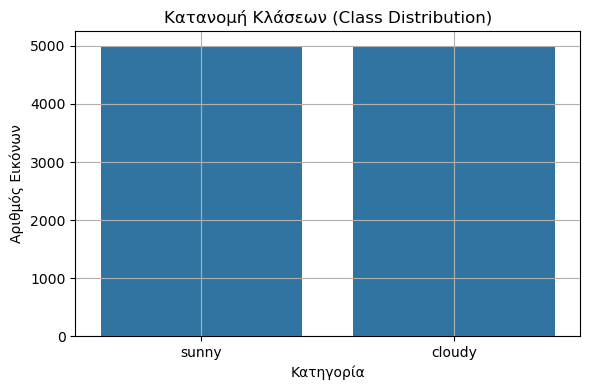

In [ ]:
# Κατανομή κλάσεων (class distribution)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Κατανομή Κλάσεων (Class Distribution)")
plt.xlabel("Κατηγορία")
plt.ylabel("Αριθμός Εικόνων")
plt.grid(True)
plt.tight_layout()
plt.show()

----

In [ ]:
# Κρασάρει λόγω χρήσης μνήμης
# # Boxplot για έλεγχο outliers ανά κανάλι
# plt.figure(figsize=(10, 5))
# sns.boxplot(data=pd.DataFrame(all_pixels, columns=channels))
# plt.title("Έλεγχος Ακραίων Τιμών (Outliers) στα Κανάλια RGB")
# plt.grid(True)
# plt.show()

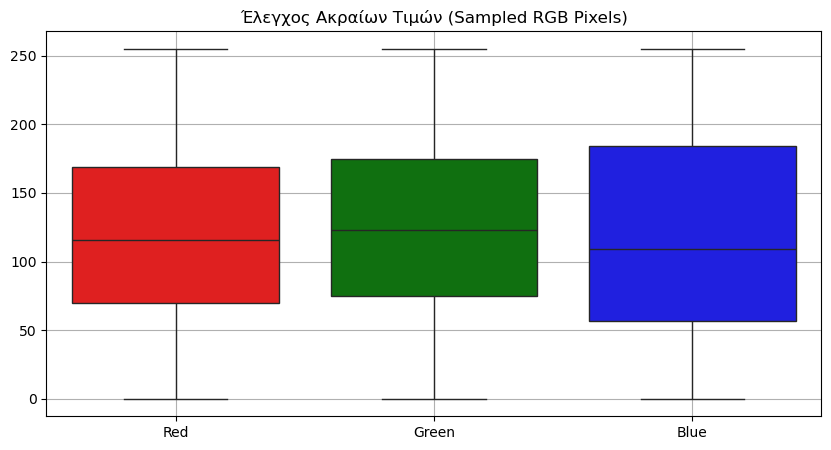

In [ ]:
# Τυχαίο δείγμα 1% των pixels για boxplot
sample_size = int(0.01 * all_pixels.shape[0])  # 1%
sampled_pixels = all_pixels[np.random.choice(all_pixels.shape[0], sample_size, replace=False)]

# Boxplot με downsampled δεδομένα
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=pd.DataFrame(sampled_pixels, columns=channels),
    palette={"Red": "red", "Green": "green", "Blue": "blue"}
)
plt.title("Έλεγχος Ακραίων Τιμών (Sampled RGB Pixels)")
plt.grid(True)
plt.show()

In [ ]:
for i, channel in enumerate(channels):
    Q1 = np.percentile(all_pixels[:, i], 25)
    Q3 = np.percentile(all_pixels[:, i], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((all_pixels[:, i] < lower_bound) | (all_pixels[:, i] > upper_bound)).sum()
    print(f"{channel}: {outliers} outliers detected.")

Red: 0 outliers detected.
Green: 0 outliers detected.
Blue: 0 outliers detected.


ΣΧΟΛΙΑ:
- Ως outliers θεωρούμε τις τιμές του pixel >250 ή <0 (αφού τα pixel αναπαρίστανται με τιμές από 0 έως 250).
    - Ίσως να διαλέξω άλλες τιμές των pixel για outlier, αλλά θέλω να το ψάξω κι άλλο +++
    - Δεν εντοπίζουμε ακραίες τιμές (outliers) στο dataset μας, κάτι το οποίο περιμέναμε αφού οι εικόνες είναι τραβηγμένες από κάμερα και η κατανομή των χρωμάτων είναι κανονική.